In [38]:
import torch
import pandas as pd
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import seaborn as sns
import random
import numpy as np
from sklearn.metrics import confusion_matrix

In [39]:
def show_samples(indices):
    plt.figure(figsize=(15, 6))

    for j, i in enumerate(indices):
        img, _ = cifar10_train[i]
        clean = df.clean_name[i]
        noisy = df.noisy_name[i]

        plt.subplot(2, 5, j + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"clean: {clean}\nnoisy: {noisy}", fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
n_path = ""#cifar-10n python file

noisy_labels = torch.load(n_path,weights_only=False)
noisy_labels.keys()

dict_keys(['clean_label', 'aggre_label', 'worse_label', 'random_label1', 'random_label2', 'random_label3'])

In [41]:
transform = transforms.ToTensor()

cifar10_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

clean = np.array(noisy_labels["clean_label"])
noisy = np.array(noisy_labels["aggre_label"])

In [42]:
df = pd.DataFrame({
    "clean_label": clean,
    "noisy_label": noisy
})
df.head()

,clean_label,noisy_label
0,6,6
1,9,9
2,9,9
3,4,4
4,1,1


In [43]:
label_names = cifar10_train.classes
df["clean_name"] = df["clean_label"].apply(lambda i: label_names[i])
df["noisy_name"] = df["noisy_label"].apply(lambda i: label_names[i])
df.sample(5)

,clean_label,noisy_label,clean_name,noisy_name
31422,9,9,truck,truck
1421,1,1,automobile,automobile
9551,6,6,frog,frog
49067,0,0,airplane,airplane
16349,2,2,bird,bird


In [44]:
mismatches = df[df["clean_label"] != df["noisy_label"]]
matches = df[df["clean_label"] == df["noisy_label"]]
print("Matches:", len(matches))
print("Mismatches:", len(mismatches))

Matches: 45495
Mismatches: 4505


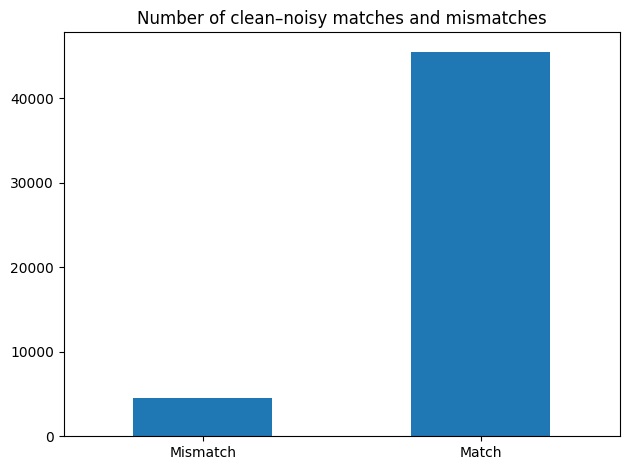

In [45]:
df["is_correct"] = df["clean_label"] == df["noisy_label"]

ax = df["is_correct"].value_counts().sort_index().plot(kind="bar")

# Remove axis label
ax.set_xlabel("")

# Set tick labels manually & rotate
ax.set_xticklabels(["Mismatch", "Match"], rotation=0)

plt.title("Number of clean–noisy matches and mismatches")
plt.tight_layout()
plt.show()

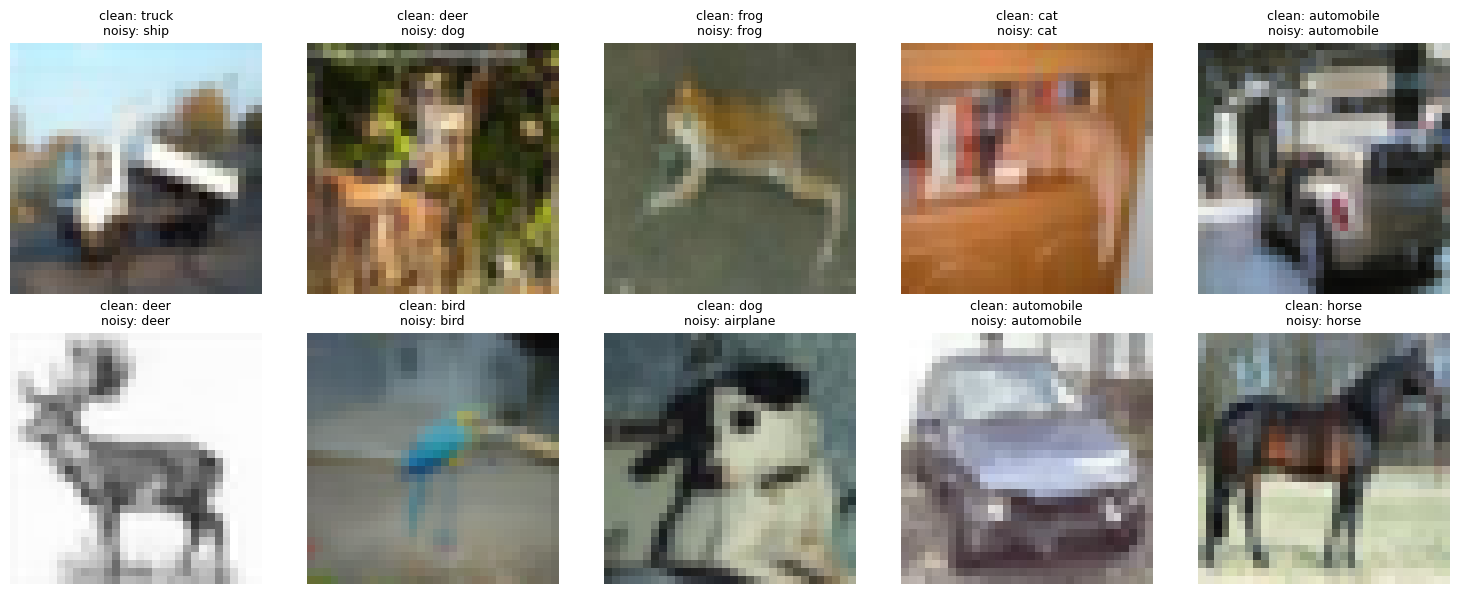

In [46]:
mismatches = df[df.clean_label != df.noisy_label].index.tolist()
matches = df[df.clean_label == df.noisy_label].index.tolist()

sample_indices = random.sample(mismatches, 3) + random.sample(matches, 7)
random.shuffle(sample_indices)

show_samples(sample_indices)

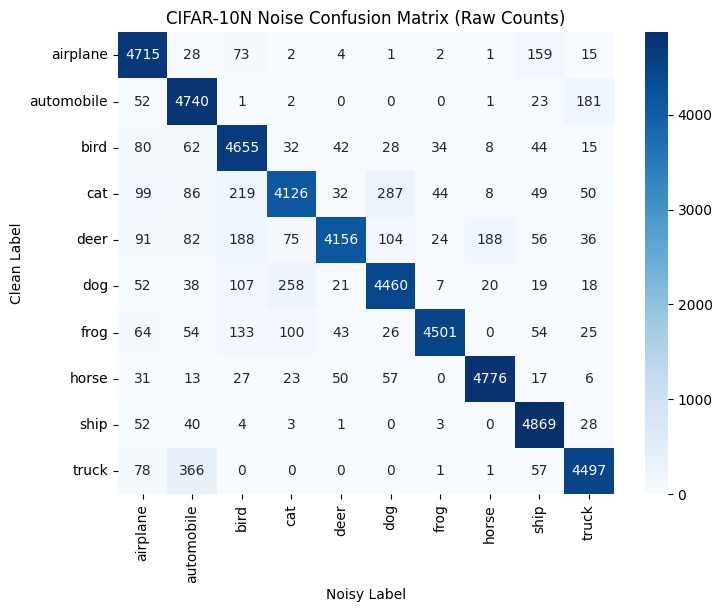

In [47]:
cclean = df["clean_label"].to_numpy()
noisy = df["noisy_label"].to_numpy()

# raw count confusion matrix
conf_mat = confusion_matrix(clean, noisy, labels=range(10))
# conf_mat

plt.figure(figsize=(8,6))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",                 # <-- show counts, not floats
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues"
)
plt.xlabel("Noisy Label")
plt.ylabel("Clean Label")
plt.title("CIFAR-10N Noise Confusion Matrix (Raw Counts)")
plt.show()

